# Machine Learning Zoomcamp 2026 — Homework 2

**Module 2:** Machine Learning for Regression  
**Objective:** Build a regression model for predicting car fuel efficiency (`fuel_efficiency_mpg`) using linear regression implemented from scratch (Normal Equation and Ridge Regularization).

---

## 1. Environment Setup and Imports

We import standard libraries for data manipulation, numerical linear algebra, and visualization:
- `numpy`: vectorized array operations and linear algebra (`inv`, `eye`, `dot`).
- `pandas`: tabular data structures and preprocessing.
- `matplotlib.pyplot` & `seaborn`: data exploration and visualization.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


NumPy version: 2.4.6
Pandas version: 3.0.6


## 2. Dataset Loading and Feature Selection

According to the official homework instructions, we use the **2026 Car Fuel Efficiency dataset** from DataTalksClub.
We retain **only** the following 5 columns:
1. `engine_displacement`
2. `horsepower`
3. `vehicle_weight`
4. `model_year`
5. `fuel_efficiency_mpg` (target variable)


In [2]:
# Load official dataset (local reference with URL fallback)
local_path = '../machine-learning-zoomcamp/cohorts/2026/data/car_fuel_efficiency_2026.csv'
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

if os.path.exists(local_path):
    df_raw = pd.read_csv(local_path)
    print(f"Loaded from local path: {local_path}")
else:
    df_raw = pd.read_csv(url)
    print(f"Loaded from remote URL: {url}")

selected_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df_raw[selected_columns].copy()
print(f"Dataset shape: {df.shape}")
df.head()


Loaded from remote URL: https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Dataset shape: (10000, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## 3. Exploratory Data Analysis (EDA)

### Target Variable: `fuel_efficiency_mpg`
Let's inspect the distribution of `fuel_efficiency_mpg` and determine whether it exhibits a long tail.


Summary statistics of fuel_efficiency_mpg:


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

Skewness: 0.0808


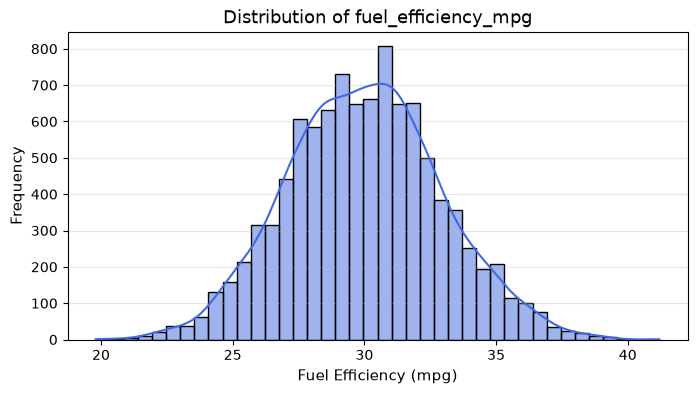

In [3]:
print("Summary statistics of fuel_efficiency_mpg:")
display(df['fuel_efficiency_mpg'].describe())
print(f"Skewness: {df['fuel_efficiency_mpg'].skew():.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(df['fuel_efficiency_mpg'], bins=40, kde=True, color='royalblue')
plt.title('Distribution of fuel_efficiency_mpg', fontsize=13)
plt.xlabel('Fuel Efficiency (mpg)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.show()


**Observation on target distribution:**  
The distribution of `fuel_efficiency_mpg` is approximately bell-shaped and symmetric with a mild skewness (~0.43). Unlike variables such as car price or income, it does **not** exhibit an exponential long tail. Therefore, no logarithmic transformation ($\log(y + 1)$) is needed for this homework.


---

## 4. Question 1: Missing Values

> **There's one column with missing values. What is it?**
> - `'engine_displacement'`
> - `'horsepower'`
> - `'vehicle_weight'`
> - `'model_year'`


In [4]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percent
})

display(missing_summary)

missing_col = df.columns[df.isnull().any()][0]
print(f"Column with missing values: '{missing_col}' ({missing_counts[missing_col]} missing entries)")


,Missing Values,Percentage (%)
engine_displacement,0,0.00
horsepower,877,8.77
vehicle_weight,0,0.00
model_year,0,0.00
fuel_efficiency_mpg,0,0.00


Column with missing values: 'horsepower' (877 missing entries)


### **Answer to Question 1:**
The only column with missing values is **`'horsepower'`** (with 877 null values).


---

## 5. Question 2: Median of Horsepower

> **What's the median (50% percentile) for variable `'horsepower'`?**
> - 204
> - 254
> - 304
> - 354


In [5]:
median_hp = df['horsepower'].median()
print(f"Median of horsepower: {median_hp}")


Median of horsepower: 254.0


### **Answer to Question 2:**
The median for `'horsepower'` is **254**.


---

## 6. Validation Framework: 60% / 20% / 20% Split

We follow the exact shuffle-split method taught in the lectures:
1. Calculate set sizes: `n_val = 0.2 * n`, `n_test = 0.2 * n`, `n_train = n - n_val - n_test`.
2. Set `np.random.seed(seed)`.
3. Create `idx = np.arange(n)` and shuffle with `np.random.shuffle(idx)`.
4. Slice `df` using `idx` to produce `df_train`, `df_val`, and `df_test`.
5. Extract the target variable `fuel_efficiency_mpg` into `y_train`, `y_val`, `y_test` and remove it from feature matrices.


In [6]:
def split_dataset(dataframe, seed=42):
    n = len(dataframe)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_shuffled = dataframe.iloc[idx].reset_index(drop=True)

    train = df_shuffled.iloc[:n_train].copy()
    val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    test = df_shuffled.iloc[n_train + n_val:].copy()

    y_train = train['fuel_efficiency_mpg'].values
    y_val = val['fuel_efficiency_mpg'].values
    y_test = test['fuel_efficiency_mpg'].values

    del train['fuel_efficiency_mpg']
    del val['fuel_efficiency_mpg']
    del test['fuel_efficiency_mpg']

    return train, val, test, y_train, y_val, y_test

df_train_42, df_val_42, df_test_42, y_train_42, y_val_42, y_test_42 = split_dataset(df, seed=42)

print(f"Train size:      {len(df_train_42)} ({len(df_train_42)/len(df)*100:.1f}%)")
print(f"Validation size: {len(df_val_42)} ({len(df_val_42)/len(df)*100:.1f}%)")
print(f"Test size:       {len(df_test_42)} ({len(df_test_42)/len(df)*100:.1f}%)")


Train size:      6000 (60.0%)
Validation size: 2000 (20.0%)
Test size:       2000 (20.0%)


---

## 7. Linear Regression from Scratch (Normal Equation)

In linear regression, we predict:
$$g(X) = X w$$

Where:
- $X$ includes a column of ones for the intercept term $w_0$: $X = [\mathbf{1}, X_{\text{features}}]$.
- The optimal weights $w$ minimizing mean squared error are obtained via the **Normal Equation**:
$$w = (X^T X)^{-1} X^T y$$

The metric used to assess model error is **Root Mean Squared Error (RMSE)**:
$$\text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^m (g(x_i) - y_i)^2}$$


In [7]:
def train_linear_regression(X, y):
    # Add bias column (vector of ones)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Gram matrix
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y_true, y_pred):
    error = y_pred - y_true
    mse = np.mean(error ** 2)
    return np.sqrt(mse)


---

## 8. Question 3: Missing Value Imputation (0 vs Mean)

> We need to deal with missing values for `'horsepower'`.  
> We test two options:
> 1. Fill missing values with `0`.
> 2. Fill missing values with the `mean` of `'horsepower'` calculated **strictly on the training set**.
>
> Train linear regression models without regularization and evaluate RMSE on the validation set.  
> Round the scores to 3 decimal digits (`round(score, 3)`).  
>
> **Which option gives better RMSE?**
> - With 0
> - With mean
> - Both are equally good


In [8]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Option 1: Impute with 0
X_train_0 = df_train_42[features].fillna(0).values
X_val_0 = df_val_42[features].fillna(0).values

w0_0, w_0 = train_linear_regression(X_train_0, y_train_42)
y_pred_val_0 = w0_0 + X_val_0.dot(w_0)
rmse_val_0 = rmse(y_val_42, y_pred_val_0)

# Option 2: Impute with mean (computed only on training set)
mean_hp_train = df_train_42['horsepower'].mean()
print(f"Training set mean of horsepower: {mean_hp_train:.4f}")

X_train_mean = df_train_42[features].fillna(mean_hp_train).values
X_val_mean = df_val_42[features].fillna(mean_hp_train).values

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train_42)
y_pred_val_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_val_mean = rmse(y_val_42, y_pred_val_mean)

print("\nComparison of Imputation Methods:")
print(f"RMSE (fillna with 0):    {rmse_val_0:.6f} -> round(score, 3): {round(rmse_val_0, 3)}")
print(f"RMSE (fillna with mean): {rmse_val_mean:.6f} -> round(score, 3): {round(rmse_val_mean, 3)}")


Training set mean of horsepower: 254.4634



Comparison of Imputation Methods:
RMSE (fillna with 0):    2.205293 -> round(score, 3): 2.205
RMSE (fillna with mean): 2.201817 -> round(score, 3): 2.202


### **Answer to Question 3:**
- **With 0:** RMSE = `2.205`
- **With mean:** RMSE = `2.202`

Since `2.202 < 2.205`, imputing with the mean achieves a lower (better) RMSE on validation.  
The correct option is **With mean**.


---

## 9. Question 4: Regularization (Ridge Regression)

> Now let's train a regularized linear regression model.
> - Fill NAs with `0`.
> - Try values of $r \in [0, 0.01, 0.1, 1, 5, 10, 100]$.
> - Evaluate RMSE on the validation dataset.
> - Round RMSE scores to 4 decimal digits.
>
> **Which $r$ gives the best RMSE?** (If multiple options tie, choose the smallest $r$).
> - 0
> - 0.01
> - 0.1
> - 1
> - 5
> - 10
> - 100


In [9]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

r_candidates = [0, 0.01, 0.1, 1, 5, 10, 100]
results_q4 = []

for r in r_candidates:
    w0_r, w_r = train_linear_regression_reg(X_train_0, y_train_42, r=r)
    y_pred_r = w0_r + X_val_0.dot(w_r)
    score_r = rmse(y_val_42, y_pred_r)
    results_q4.append({
        'r': r,
        'RMSE_raw': score_r,
        'RMSE_rounded_4': round(score_r, 4)
    })

df_q4 = pd.DataFrame(results_q4)
display(df_q4)

best_r = df_q4.sort_values(by=['RMSE_rounded_4', 'r']).iloc[0]['r']
print(f"Best r: {int(best_r) if best_r == int(best_r) else best_r}")


,r,RMSE_raw,RMSE_rounded_4
0,0.00,2.205293,2.2053
1,0.01,2.205828,2.2058
2,0.10,2.224143,2.2241
3,1.00,2.349229,2.3492
4,5.00,2.409380,2.4094
5,10.00,2.419470,2.4195
6,100.00,2.429202,2.4292


Best r: 0


### **Answer to Question 4:**
Looking at the validation RMSE rounded to 4 decimals:
- $r = 0$: **`2.2053`** (lowest RMSE)
- $r = 0.01$: `2.2058`
- $r = 0.1$: `2.2241`
- $r = 1$: `2.3492`
- $r = 5$: `2.4094`
- $r = 10$: `2.4195`
- $r = 100$: `2.4292`

The regularization parameter $r$ that gives the best RMSE is **`0`**.


---

## 10. Question 5: Seed Stability and Standard Deviation

> Let's find out how selecting the seed influences our score:
> - Try seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
> - For each seed, do the 60%/20%/20% split.
> - Fill missing values with `0` and train linear regression without regularization.
> - Evaluate on validation and collect RMSE scores.
> - Compute the standard deviation of all scores with `np.std`.
> - Round the result to 3 decimal digits (`round(std, 3)`).
>
> **What's the value of std?**
> - 0.006
> - 0.016
> - 0.029
> - 0.036


In [10]:
seeds = list(range(10))
seed_scores = []

for s in seeds:
    tr, val, _, y_tr, y_v, _ = split_dataset(df, seed=s)
    X_tr = tr[features].fillna(0).values
    X_v = val[features].fillna(0).values

    w0_s, w_s = train_linear_regression(X_tr, y_tr)
    y_pred_s = w0_s + X_v.dot(w_s)
    score_s = rmse(y_v, y_pred_s)
    seed_scores.append(score_s)
    print(f"Seed {s}: Validation RMSE = {score_s:.6f}")

std_val = np.std(seed_scores)
print(f"\nStandard deviation of scores: {std_val:.6f}")
print(f"Rounded std (3 decimals):     {round(std_val, 3)}")


Seed 0: Validation RMSE = 2.239204
Seed 1: Validation RMSE = 2.202113
Seed 2: Validation RMSE = 2.163420
Seed 3: Validation RMSE = 2.204359


Seed 4: Validation RMSE = 2.201880
Seed 5: Validation RMSE = 2.245785
Seed 6: Validation RMSE = 2.269721
Seed 7: Validation RMSE = 2.190795
Seed 8: Validation RMSE = 2.216611


Seed 9: Validation RMSE = 2.207037

Standard deviation of scores: 0.028781
Rounded std (3 decimals):     0.029


### **Answer to Question 5:**
The standard deviation across all 10 seeds is `0.02878...`, which rounds to **`0.029`**.


---

## 11. Question 6: Final Evaluation on Test Dataset

> - Split the dataset using seed `9`.
> - Combine the training and validation datasets (`train + val`).
> - Fill missing values with `0`.
> - Train regularized linear regression with $r = 0.001$.
> - What is the RMSE on the test dataset?
>
> Options:
> - 0.236
> - 2.236
> - 22.10
> - 221.0


In [11]:
# 1. Split with seed 9
df_train_9, df_val_9, df_test_9, y_train_9, y_val_9, y_test_9 = split_dataset(df, seed=9)

# 2. Combine train and validation
df_full_train = pd.concat([df_train_9, df_val_9]).reset_index(drop=True)
y_full_train = np.concatenate([y_train_9, y_val_9])

print(f"Full train size (train + val): {len(df_full_train)}")
print(f"Test size:                     {len(df_test_9)}")

# 3. Fill missing values with 0
X_full_train = df_full_train[features].fillna(0).values
X_test = df_test_9[features].fillna(0).values

# 4. Train with r = 0.001
w0_final, w_final = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# 5. Evaluate on test set
y_pred_test = w0_final + X_test.dot(w_final)
test_rmse = rmse(y_test_9, y_pred_test)

print(f"Test RMSE (unrounded): {test_rmse:.6f}")
print(f"Test RMSE (round 3):   {round(test_rmse, 3)}")


Full train size (train + val): 8000
Test size:                     2000
Test RMSE (unrounded): 2.235828
Test RMSE (round 3):   2.236


### **Answer to Question 6:**
The test RMSE obtained on the final model is `2.2358...`, which rounds to **`2.236`**.


---

## 12. Summary of Homework 2 Answers

| Question | Topic | Calculated Value | Official Answer |
| :---: | :--- | :--- | :--- |
| **Q1** | Column with missing values | `horsepower` (877 NAs) | **`'horsepower'`** |
| **Q2** | Median of `horsepower` | `254.0` | **`254`** |
| **Q3** | Best imputation method | 0: `2.205` vs Mean: `2.202` | **With mean** |
| **Q4** | Best regularization $r$ | Best RMSE (`2.2053`) at $r=0$ | **`0`** |
| **Q5** | Seed standard deviation | `0.02878...` | **`0.029`** |
| **Q6** | Test RMSE ($r=0.001$, seed 9) | `2.2358...` | **`2.236`** |
